In [17]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt

In [18]:
# TensorFlow & Keras
import sklearn
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

In [19]:
import tensorflow as tf
print(tf.__version__)


2.20.0


In [20]:
df= pd.read_csv('data/Phishing_Email.csv')

In [21]:
df

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email
...,...,...,...
18645,18646,date a lonely housewife always wanted to date ...,Phishing Email
18646,18647,request submitted : access request for anita ....,Safe Email
18647,18648,"re : important - prc mtg hi dorn & john , as y...",Safe Email
18648,18649,press clippings - letter on californian utilit...,Safe Email


In [22]:
df.rename(columns = {'Unnamed: 0': 'no','Email Text':'email_text', 'Email Type': 'outcome'}, inplace = True)


In [23]:
df

,no,email_text,outcome
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email
...,...,...,...
18645,18646,date a lonely housewife always wanted to date ...,Phishing Email
18646,18647,request submitted : access request for anita ....,Safe Email
18647,18648,"re : important - prc mtg hi dorn & john , as y...",Safe Email
18648,18649,press clippings - letter on californian utilit...,Safe Email


In [24]:
print(df.columns.tolist())

['no', 'email_text', 'outcome']


## Data_Preprocessing and cleaning

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   no          18650 non-null  int64 
 1   email_text  18634 non-null  object
 2   outcome     18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB


In [26]:
df.isnull().sum()

no             0
email_text    16
outcome        0
dtype: int64

In [29]:
df = df.dropna(subset=['email_text'])     #To drop only null values comlmns


In [30]:
df.isnull().sum()

no            0
email_text    0
outcome       0
dtype: int64

In [31]:
#Duplication check kry gay
df.duplicated().sum()

np.int64(0)

In [32]:
#drop unmessory colmn
df = df.drop(columns = ['no'])

In [33]:
df.shape

(18634, 2)

### Email Text cleaning

In [34]:
df['email_text'] = df['email_text'].str.lower()

In [35]:
df['email_text'] = df['email_text'].apply(lambda x: re.sub(r'\S+@\S+', 'EMAIL', str(x)))


In [36]:
# Replace all numbers with 'NUM'
df['email_text'] = df['email_text'].apply(lambda x: re.sub(r'\d+', 'NUM', str(x)))


In [37]:
# Remove extra whitespace
df['email_text'] = df['email_text'].apply(lambda x: re.sub(r'\s+', ' ', str(x)).strip())


In [38]:
# df = df[df['email_text'].str.len() > 10]
# df.shape


### To covert outcome colmn in binary

In [39]:
df.loc[:, 'outcome'] = df['outcome'].map({'Safe Email': 0, 'Phishing Email': 1})


In [40]:
df

,email_text,outcome
0,"re : NUM . NUM , disc : uniformitarianism , re...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,hello i am your hot lil horny toy. i am the on...,1
4,software at incredibly low prices ( NUM % lowe...,1
...,...,...
18645,date a lonely housewife always wanted to date ...,1
18646,request submitted : access request for anita ....,0
18647,"re : important - prc mtg hi dorn & john , as y...",0
18648,press clippings - letter on californian utilit...,0


## Training

In [41]:
x= df['email_text'] 
y= df['outcome'] 

In [42]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Keep same ratio of phishing/safe in both sets
)

In [44]:
MAX_WORDS = 5000  # Use top 5000 most frequent words
MAX_LENGTH = 100  # Each email will be represented by 100 numbers

In [46]:
# Create tokenizer
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train)

In [47]:
print(f"Total unique words found: {len(tokenizer.word_index)}")

Total unique words found: 137352


In [48]:
X_train_seq = tokenizer.texts_to_sequences(x_train)
X_test_seq = tokenizer.texts_to_sequences(x_test)

In [49]:
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_LENGTH, padding='post', truncating='post')

In [50]:
model = keras.Sequential([
    # Layer 1: Embedding - converts word indices to dense vectors
    layers.Embedding(
        input_dim=MAX_WORDS,  # Vocabulary size
        output_dim=32,         # Embedding dimension
        input_length=MAX_LENGTH
    ),
    
    # Layer 2: LSTM - learns sequential patterns in text
    layers.LSTM(64, return_sequences=True),
    
    # Layer 3: Another LSTM layer
    layers.LSTM(32),
    
    # Layer 4: Dense layer with ReLU activation
    layers.Dense(64, activation='relu'),
    
    # Layer 5: Dropout to prevent overfitting
    layers.Dropout(0.5),
    
    # Output layer: Binary classification (0 or 1)
    layers.Dense(1, activation='sigmoid')
])

C:\Users\wajid khan\.conda\envs\cyberguard\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [51]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [55]:
print(X_train_padded.dtype)
print(y_train.dtype)
y_train = np.array(y_train, dtype=np.int32)

int32
object


In [56]:
history = model.fit(
    X_train_padded,
    y_train,
    epochs=10,           # Number of training iterations
    batch_size=32,       # Process 32 emails at a time
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1             # Show progress
)

Epoch 1/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 64s 147ms/step - accuracy: 0.6843 - loss: 0.5936 - val_accuracy: 0.7978 - val_loss: 0.5025
Epoch 2/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 53s 142ms/step - accuracy: 0.8112 - loss: 0.4920 - val_accuracy: 0.7394 - val_loss: 0.4758
Epoch 3/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 51s 137ms/step - accuracy: 0.7017 - loss: 0.5511 - val_accuracy: 0.6476 - val_loss: 0.5556
Epoch 4/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 52s 138ms/step - accuracy: 0.6801 - loss: 0.5457 - val_accuracy: 0.8333 - val_loss: 0.4095
Epoch 5/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 52s 140ms/step - accuracy: 0.8607 - loss: 0.3747 - val_accuracy: 0.8887 - val_loss: 0.3240
Epoch 6/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 50s 134ms/step - accuracy: 0.8761 - loss: 0.3279 - val_accuracy: 0.8763 - val_loss: 0.2787
Epoch 7/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 50s 134ms/step - accuracy: 0.8879 - loss: 0.2866 - val_accuracy: 0.9125 - val_loss: 0.2123
Epoch 8/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 52s 140ms/step - accuracy: 0.9252 - loss: 0

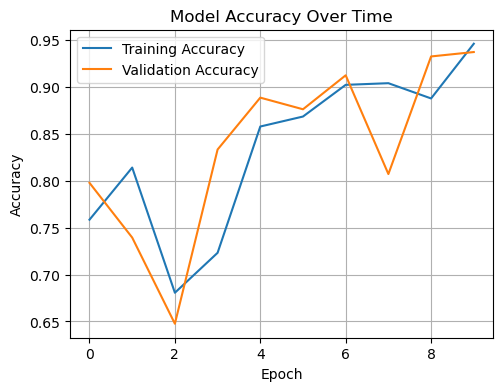

In [57]:
# Plot training history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

In [61]:
y_test = np.array(y_test, dtype=np.int32)
print(X_test_padded.dtype)
print(y_test.dtype)


int32
int32


In [62]:
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=0)

In [63]:
if test_accuracy >= 0.90:
    print("\n✅ EXCELLENT! Your model is highly accurate!")
elif test_accuracy >= 0.85:
    print("\n✅ VERY GOOD! Model performance is strong!")
elif test_accuracy >= 0.75:
    print("\n✅ GOOD! Model is working well!")
else:
    print("\n⚠️ Model accuracy is moderate. Consider:")
    print("   - More training data")
    print("   - More epochs")
    print("   - Different model architecture")


✅ EXCELLENT! Your model is highly accurate!


In [73]:
import os
# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

print("Saving trained model and tokenizer...\n")

# Save model
model.save('../models/phishing_detector.keras')
print("✅ Model saved: models/phishing_detector.keras")

# Save tokenizer
with open('../models/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✅ Tokenizer saved: models/tokenizer.pkl")

# Save configuration
TEXT_COLUMN = 'email_text'   # your text column
LABEL_COLUMN = 'outcome'     # your label column

config = {
    'MAX_WORDS': MAX_WORDS,
    'MAX_LENGTH': MAX_LENGTH,
    'test_accuracy': test_accuracy,
    'text_column': TEXT_COLUMN,
    'label_column': LABEL_COLUMN
}
with open('../models/config.pkl', 'wb') as f:
    pickle.dump(config, f)
print("✅ Config saved: models/config.pkl")

Saving trained model and tokenizer...

✅ Model saved: models/phishing_detector.keras
✅ Tokenizer saved: models/tokenizer.pkl
✅ Config saved: models/config.pkl
